In [13]:
import os, math, random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, Subset, DataLoader
import torchvision as tv
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Setup & Transforms

In [14]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
histories = {}

train_tf = T.Compose([
    T.RandomResizedCrop(64),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tf = T.Compose([
    T.Resize(64),
    T.CenterCrop(64),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

dataset_path = "./tiny-imagenet-200"
if not os.path.exists(dataset_path):
    os.system("wget http://cs231n.stanford.edu/tiny-imagenet-200.zip -O tiny-imagenet.zip")
    os.system("unzip tiny-imagenet.zip -d ./")
    print("Tiny ImageNet downloaded and unzipped.")

# Load train/val datasets

In [ ]:
full_train_set = tv.datasets.ImageFolder(os.path.join(dataset_path, "train"), transform=train_tf)

val_annotations_file = os.path.join(dataset_path, "val", "val_annotations.txt")
val_img_to_label = {}
with open(val_annotations_file) as f:
    for line in f:
        parts = line.strip().split("\t")
        val_img_to_label[parts[0]] = parts[1]

full_val_set = tv.datasets.ImageFolder(os.path.join(dataset_path, "val"), transform=val_tf)
val_samples = []
for path, _ in full_val_set.samples:
    img_name = os.path.basename(path)
    wnid = val_img_to_label[img_name]
    label = full_train_set.class_to_idx[wnid]
    val_samples.append((path, label))
full_val_set.samples = val_samples
full_val_set.targets = [lbl for _, lbl in val_samples]

# Pick 20 classes ONCE and build mapping to 0..19

In [ ]:
all_classes = full_train_set.classes  
selected_classes = sorted(random.sample(all_classes, 20))  
orig_to_new = {full_train_set.class_to_idx[c]: i for i, c in enumerate(selected_classes)}

# Filter indices to selected classes (using samples metadata, no transforms)

In [17]:
def filter_indices_by_classes(dataset, classes_new_map):
    keep = []
    for i, (_, orig_lbl) in enumerate(dataset.samples):
        if orig_lbl in classes_new_map:
            keep.append(i)
    return keep

train_indices = filter_indices_by_classes(full_train_set, orig_to_new)
val_indices   = filter_indices_by_classes(full_val_set,   orig_to_new)

train_subset = Subset(full_train_set, train_indices)
val_subset   = Subset(full_val_set,   val_indices)

# Label remapper so targets are in 0..19

In [18]:
class LabelRemapSubset(Dataset):
    def __init__(self, subset, orig_to_new_map):
        self.subset = subset
        self.map = orig_to_new_map
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return x, self.map[y]

train_set_20 = LabelRemapSubset(train_subset, orig_to_new)
val_set_20   = LabelRemapSubset(val_subset,   orig_to_new)

# DataLoaders

In [19]:
num_workers = 4
train_loader = DataLoader(train_set_20, batch_size=128, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_set_20,   batch_size=256, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"Train samples: {len(train_set_20)}, Val samples: {len(val_set_20)}")
print(f"Selected classes (wnids): {selected_classes}")

Train samples: 10000, Val samples: 1000
Selected classes (wnids): ['n01629819', 'n01950731', 'n01983481', 'n02099712', 'n02231487', 'n02415577', 'n02480495', 'n02793495', 'n02837789', 'n02906734', 'n03026506', 'n03160309', 'n03930313', 'n03977966', 'n04179913', 'n04275548', 'n04501370', 'n04507155', 'n07615774', 'n07873807']


# ViT building blocks

In [ ]:
def sinusoidal_2d(h, w, dim):
    pe = torch.zeros(1, h*w, dim)
    dim_half = dim // 2
    y, x = torch.meshgrid(torch.arange(h), torch.arange(w), indexing='ij')
    div = torch.exp(torch.arange(0, dim_half, 2) * (-math.log(10000.0) / dim_half))
    pe[:, :, 0:dim_half:2] = torch.sin(x.reshape(-1, 1) * div)
    pe[:, :, 1:dim_half:2] = torch.cos(x.reshape(-1, 1) * div)
    pe[:, :, dim_half::2]  = torch.sin(y.reshape(-1, 1) * div)
    pe[:, :, dim_half+1::2]= torch.cos(y.reshape(-1, 1) * div)
    return pe  

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_ch=3, embed_dim=768, kind="conv"):
        super().__init__()
        self.grid = img_size // patch_size
        if kind == "conv":
            self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        else:
            self.proj = None
            self.ps = patch_size
            self.lin = nn.Linear(in_ch * patch_size * patch_size, embed_dim)

    def forward(self, x):
        if self.proj is not None:
            x = self.proj(x)                       # (B, D, H', W')
            x = x.flatten(2).transpose(1, 2)       # (B, N, D)
        else:
            B, C, H, W = x.shape
            ps = self.ps
            x = x.unfold(2, ps, ps).unfold(3, ps, ps)  # (B,C,g,g,ps,ps)
            x = x.contiguous().permute(0, 2, 3, 1, 4, 5).reshape(B, -1, C*ps*ps)
            x = self.lin(x)                        # (B, N, D)
        return x

class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop)
        )
    def forward(self, x): return self.net(x)

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, attn_drop=0.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads, dropout=attn_drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, drop)
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img_size=64, patch_size=16, in_ch=3, num_classes=20,
                 embed_dim=384, depth=8, num_heads=6,
                 patch_kind="conv", pos_kind="learned", drop=0.0):
        super().__init__()
        self.patch = PatchEmbed(img_size, patch_size, in_ch, embed_dim, kind=patch_kind)
        self.cls = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_kind = pos_kind
        self.grid = img_size // patch_size
        self.pos = nn.Parameter(torch.zeros(1, 1 + self.grid*self.grid, embed_dim)) if pos_kind == "learned" else None
        self.blocks = nn.Sequential(*[Block(embed_dim, num_heads, drop=drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls, std=0.02)
        if self.pos is not None:
            nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x):
        x = self.patch(x)                 # (B, N, D)
        B, N, D = x.shape
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)    # (B, 1+N, D)
        if self.pos_kind == "learned":
            x = x + self.pos[:, :N+1, :]
        else:
            pe = sinusoidal_2d(self.grid, self.grid, D).to(x.device)
            x[:, 1:, :] = x[:, 1:, :] + pe[:, :N, :]
        x = self.blocks(x)
        x = self.norm(x)
        return self.head(x[:, 0])

# Baseline CNN

In [21]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=20):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.classifier(x)

# Baseline FCFNN

In [22]:
class FCFNN(nn.Module):
    def __init__(self, num_classes=20, in_hw=64):
        super().__init__()
        d = 3 * in_hw * in_hw
        self.net = nn.Sequential(
            nn.Linear(d, 2048), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(2048, 1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, num_classes)
        )
    def forward(self, x):
        return self.net(x.flatten(1))

# Train / Eval helpers

In [23]:
def train_one_epoch(model, loader, opt, loss_fn, device):
    model.train(); total=correct=0; running=0.0
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward(); opt.step()
        running += loss.item() * x.size(0)
        pred = logits.argmax(1); correct += (pred==y).sum().item(); total += y.size(0)
    return running/total, correct/total

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval(); total=correct=0; running=0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x); loss = loss_fn(logits, y)
        running += loss.item() * x.size(0)
        pred = logits.argmax(1); correct += (pred==y).sum().item(); total += y.size(0)
    return running/total, correct/total

def run(model, train_loader, val_loader, epochs=30, lr=3e-4, wd=0.05):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn, device)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn, device)
        sched.step()
        print(f"[{ep:02d}] train {tr_acc:.3f} val {va_acc:.3f} | loss {va_loss:.3f}")
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
    return history

# ViT Training

In [24]:

vit = ViT(num_classes=20, embed_dim=384, depth=8, num_heads=6, patch_size=16,
          patch_kind="conv", pos_kind="learned", img_size=64)
histories["ViT"] = run(vit, train_loader, val_loader, epochs=30)

[01] train 0.171 val 0.209 | loss 2.521
[02] train 0.224 val 0.247 | loss 2.417
[03] train 0.258 val 0.271 | loss 2.353
[04] train 0.282 val 0.279 | loss 2.280
[05] train 0.302 val 0.286 | loss 2.236
[06] train 0.317 val 0.325 | loss 2.165
[07] train 0.330 val 0.329 | loss 2.119
[08] train 0.338 val 0.327 | loss 2.143
[09] train 0.346 val 0.363 | loss 2.077
[10] train 0.361 val 0.361 | loss 2.058
[11] train 0.376 val 0.353 | loss 2.081
[12] train 0.378 val 0.371 | loss 2.026
[13] train 0.385 val 0.382 | loss 1.982
[14] train 0.401 val 0.389 | loss 1.982
[15] train 0.411 val 0.383 | loss 1.954
[16] train 0.412 val 0.414 | loss 1.934
[17] train 0.426 val 0.419 | loss 1.909
[18] train 0.440 val 0.418 | loss 1.921
[19] train 0.441 val 0.419 | loss 1.881
[20] train 0.460 val 0.433 | loss 1.868
[21] train 0.466 val 0.435 | loss 1.846
[22] train 0.472 val 0.447 | loss 1.826
[23] train 0.475 val 0.448 | loss 1.796
[24] train 0.496 val 0.448 | loss 1.799
[25] train 0.499 val 0.442 | loss 1.811


# CNN Training

In [25]:
cnn = SmallCNN(num_classes=20)
histories["CNN"] = run(cnn, train_loader, val_loader, epochs=30, lr=1e-3, wd=1e-4)

[01] train 0.243 val 0.237 | loss 2.610
[02] train 0.327 val 0.297 | loss 2.344
[03] train 0.355 val 0.333 | loss 2.244
[04] train 0.384 val 0.293 | loss 2.388
[05] train 0.398 val 0.362 | loss 2.069
[06] train 0.418 val 0.358 | loss 2.109
[07] train 0.430 val 0.403 | loss 1.912
[08] train 0.444 val 0.385 | loss 2.020
[09] train 0.442 val 0.346 | loss 2.127
[10] train 0.457 val 0.413 | loss 1.836
[11] train 0.470 val 0.396 | loss 1.948
[12] train 0.481 val 0.419 | loss 1.854
[13] train 0.491 val 0.373 | loss 2.007
[14] train 0.490 val 0.417 | loss 1.856
[15] train 0.492 val 0.481 | loss 1.720
[16] train 0.502 val 0.474 | loss 1.692
[17] train 0.506 val 0.423 | loss 1.984
[18] train 0.517 val 0.492 | loss 1.634
[19] train 0.519 val 0.496 | loss 1.582
[20] train 0.521 val 0.504 | loss 1.535
[21] train 0.522 val 0.522 | loss 1.545
[22] train 0.526 val 0.531 | loss 1.511
[23] train 0.538 val 0.507 | loss 1.546
[24] train 0.549 val 0.521 | loss 1.530
[25] train 0.539 val 0.536 | loss 1.468


# FCFNN training
* FCNN uses flattened inputs; make transformed subsets on top of (remapped) subsets

In [26]:
fc_train_tf = T.Compose([
    T.Resize((64,64)),  # works on tensors too in torchvision >=0.8
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.Lambda(lambda x: x.flatten())
])
fc_val_tf = T.Compose([
    T.Resize((64,64)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.Lambda(lambda x: x.flatten())
])


class TransformedSubset(Dataset):
    def __init__(self, base_subset, transform):
        self.base = base_subset
        self.transform = transform
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        x, y = self.base[idx]
        return self.transform(x), y

fc_train_set = TransformedSubset(train_set_20, fc_train_tf)
fc_val_set   = TransformedSubset(val_set_20,   fc_val_tf)

fc_train_loader = DataLoader(fc_train_set, batch_size=64, shuffle=True,  num_workers=num_workers, pin_memory=True)
fc_val_loader   = DataLoader(fc_val_set,   batch_size=64, shuffle=False, num_workers=num_workers, pin_memory=True)

fc = FCFNN(num_classes=20, in_hw=64)
histories["FCFNN"] = run(fc, fc_train_loader, fc_val_loader, epochs=30, lr=1e-3, wd=1e-4)

[01] train 0.076 val 0.103 | loss 2.901
[02] train 0.088 val 0.116 | loss 2.835
[03] train 0.095 val 0.114 | loss 2.832
[04] train 0.100 val 0.156 | loss 2.783
[05] train 0.096 val 0.145 | loss 2.810
[06] train 0.110 val 0.157 | loss 2.810
[07] train 0.114 val 0.145 | loss 2.757
[08] train 0.113 val 0.137 | loss 2.782
[09] train 0.111 val 0.145 | loss 2.766
[10] train 0.115 val 0.158 | loss 2.757
[11] train 0.121 val 0.169 | loss 2.683
[12] train 0.117 val 0.152 | loss 2.740
[13] train 0.119 val 0.165 | loss 2.682
[14] train 0.128 val 0.154 | loss 2.708
[15] train 0.132 val 0.196 | loss 2.656
[16] train 0.139 val 0.181 | loss 2.642
[17] train 0.138 val 0.183 | loss 2.650
[18] train 0.148 val 0.184 | loss 2.612
[19] train 0.145 val 0.190 | loss 2.605
[20] train 0.155 val 0.204 | loss 2.602
[21] train 0.156 val 0.198 | loss 2.607
[22] train 0.160 val 0.208 | loss 2.569
[23] train 0.163 val 0.206 | loss 2.570
[24] train 0.165 val 0.220 | loss 2.544
[25] train 0.170 val 0.219 | loss 2.533


# Plot curves & final comparison

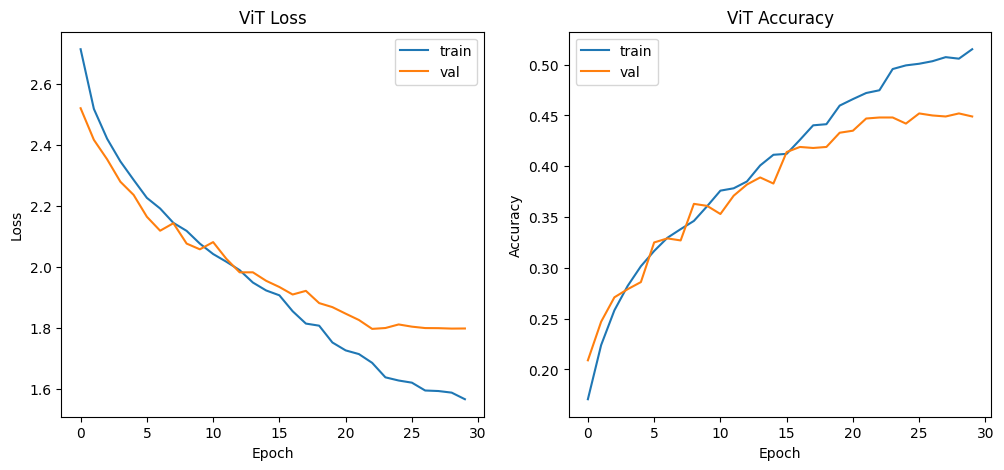

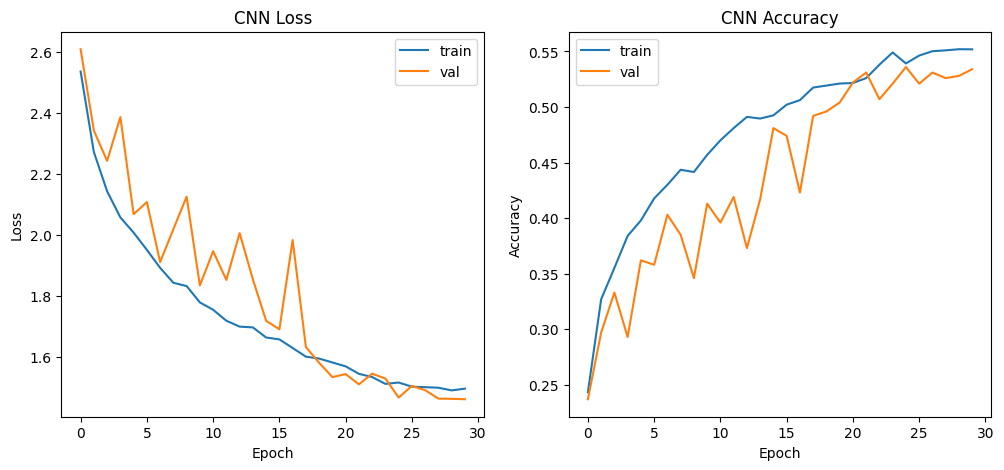

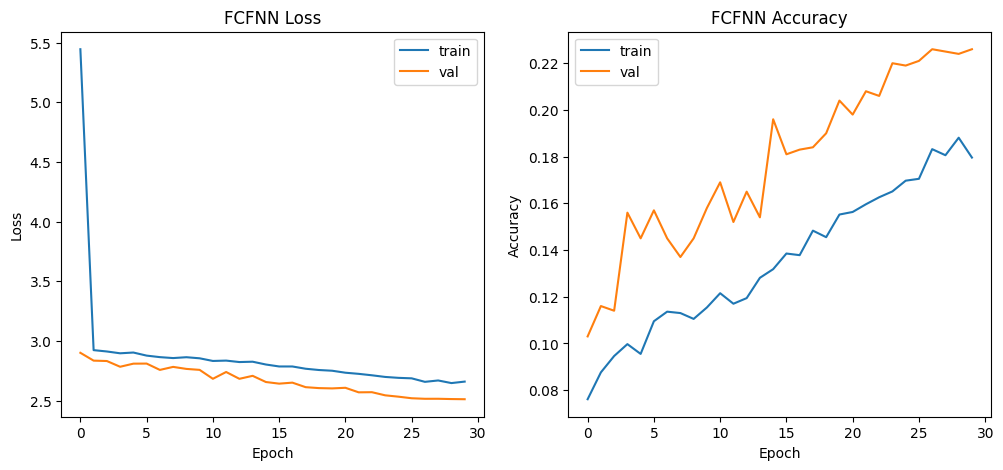

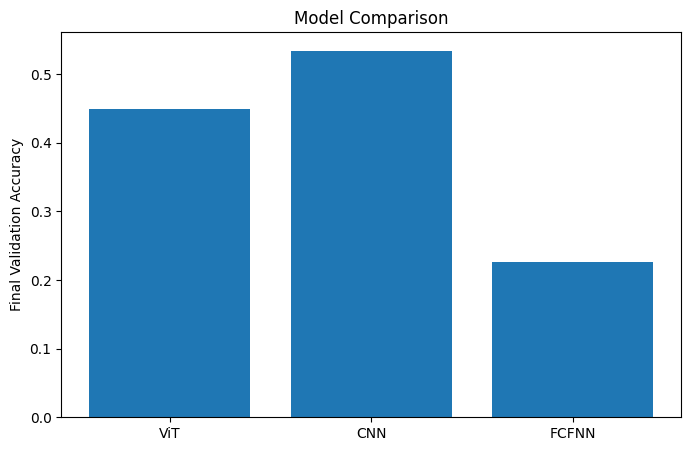

In [27]:
for model_name, h in histories.items():
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(h["train_loss"], label="train")
    plt.plot(h["val_loss"], label="val")
    plt.title(f"{model_name} Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(h["train_acc"], label="train")
    plt.plot(h["val_acc"], label="val")
    plt.title(f"{model_name} Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.show()

final_val_accs = {name: h["val_acc"][-1] for name, h in histories.items()}
plt.figure(figsize=(8,5))
plt.bar(final_val_accs.keys(), final_val_accs.values())
plt.ylabel("Final Validation Accuracy")
plt.title("Model Comparison")
plt.show()


In [28]:
final_accs = {}
for name, hist in histories.items():
    if "val_acc" in hist:
        final_accs[name] = hist["val_acc"][-1] * 100

# Pretty print
print("Final Validation Accuracies")
for name, acc in final_accs.items():
    print(f"{name:10s}: {acc:.2f}%")

Final Validation Accuracies
ViT       : 44.90%
CNN       : 53.40%
FCFNN     : 22.60%


# Different accuracy for using different number of heads for ViT [2,4,6,8]

In [29]:
for heads in [2,4,6,8]:
    vit = ViT(num_classes=20, embed_dim=384, depth=8,
              num_heads=heads, patch_size=16,
              patch_kind="conv", pos_kind="learned")
    name = f"ViT-h{heads}"
    histories[name] = run(vit, train_loader, val_loader, epochs=30, lr=1e-3, wd=1e-4)


[01] train 0.145 val 0.181 | loss 2.655
[02] train 0.173 val 0.182 | loss 2.577
[03] train 0.191 val 0.192 | loss 2.584
[04] train 0.207 val 0.193 | loss 2.599
[05] train 0.213 val 0.212 | loss 2.498
[06] train 0.220 val 0.210 | loss 2.529
[07] train 0.224 val 0.199 | loss 2.537
[08] train 0.222 val 0.208 | loss 2.540
[09] train 0.186 val 0.202 | loss 2.548
[10] train 0.196 val 0.188 | loss 2.593
[11] train 0.203 val 0.202 | loss 2.539
[12] train 0.201 val 0.172 | loss 2.580
[13] train 0.205 val 0.218 | loss 2.510
[14] train 0.222 val 0.206 | loss 2.565
[15] train 0.224 val 0.206 | loss 2.528
[16] train 0.234 val 0.229 | loss 2.456
[17] train 0.241 val 0.235 | loss 2.419
[18] train 0.252 val 0.249 | loss 2.429
[19] train 0.242 val 0.226 | loss 2.506
[20] train 0.246 val 0.268 | loss 2.403
[21] train 0.261 val 0.254 | loss 2.382
[22] train 0.262 val 0.265 | loss 2.361
[23] train 0.266 val 0.254 | loss 2.370
[24] train 0.286 val 0.269 | loss 2.347
[25] train 0.277 val 0.269 | loss 2.331


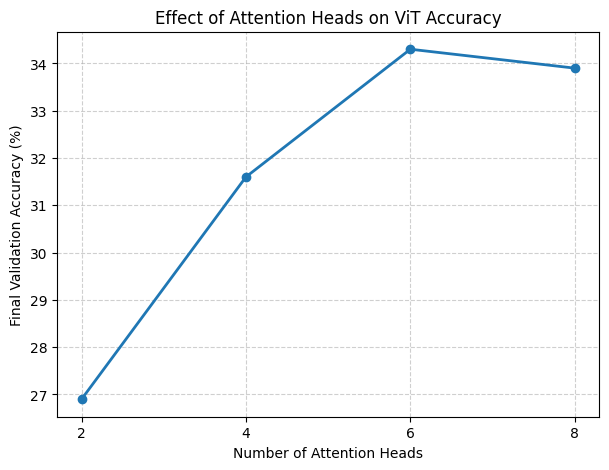

In [30]:
head_accs = {}
for heads in [2, 4, 6, 8]:
    name = f"ViT-h{heads}"
    head_accs[heads] = histories[name]["val_acc"][-1] * 100 

plt.figure(figsize=(7,5))
plt.plot(list(head_accs.keys()), list(head_accs.values()), marker="o", linewidth=2)

plt.title("Effect of Attention Heads on ViT Accuracy")
plt.xlabel("Number of Attention Heads")
plt.ylabel("Final Validation Accuracy (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks([2,4,6,8])
plt.show()

# Accuracy comparison for all models 

In [31]:
print("=== Final Validation Accuracies ===")
print(f"CNN       : {histories['CNN']['val_acc'][-1]*100:.2f}%")
print(f"FCFNN     : {histories['FCFNN']['val_acc'][-1]*100:.2f}%")
for heads in [2, 4, 6, 8]:
    name = f"ViT-h{heads}"
    print(f"{name:<9}: {histories[name]['val_acc'][-1]*100:.2f}%")


=== Final Validation Accuracies ===
CNN       : 53.40%
FCFNN     : 22.60%
ViT-h2   : 26.90%
ViT-h4   : 31.60%
ViT-h6   : 34.30%
ViT-h8   : 33.90%


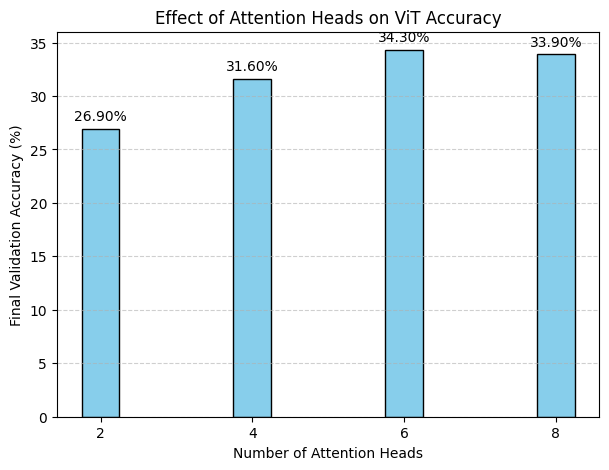

In [32]:
head_accs = {}
for heads in [2, 4, 6, 8]:
    name = f"ViT-h{heads}"
    head_accs[heads] = histories[name]["val_acc"][-1] * 100  # percentage

plt.figure(figsize=(7,5))
plt.bar(list(head_accs.keys()), list(head_accs.values()), width=0.5, color="skyblue", edgecolor="black")
plt.title("Effect of Attention Heads on ViT Accuracy")
plt.xlabel("Number of Attention Heads")
plt.ylabel("Final Validation Accuracy (%)")
plt.xticks([2,4,6,8])
plt.grid(axis="y", linestyle="--", alpha=0.6)

for x, y in head_accs.items():
    plt.text(x, y+0.5, f"{y:.2f}%", ha="center", va="bottom", fontsize=10)

plt.show()


# Train different patch embedding choses

In [33]:
patch_accs = {}
for patch_kind in ["linear", "conv"]:
    vit = ViT(num_classes=20, embed_dim=384, depth=8,
              num_heads=6, patch_size=16,
              patch_kind=patch_kind, pos_kind="learned")
    name = f"ViT-{patch_kind}"
    histories[name] = run(vit, train_loader, val_loader, epochs=30, lr=1e-3, wd=1e-4)
    patch_accs[patch_kind] = histories[name]["val_acc"][-1] * 100


[01] train 0.135 val 0.156 | loss 2.657
[02] train 0.182 val 0.204 | loss 2.524
[03] train 0.211 val 0.213 | loss 2.509
[04] train 0.225 val 0.189 | loss 2.506
[05] train 0.237 val 0.246 | loss 2.480
[06] train 0.236 val 0.213 | loss 2.453
[07] train 0.245 val 0.268 | loss 2.377
[08] train 0.246 val 0.265 | loss 2.389
[09] train 0.255 val 0.235 | loss 2.435
[10] train 0.257 val 0.258 | loss 2.367
[11] train 0.258 val 0.245 | loss 2.396
[12] train 0.258 val 0.264 | loss 2.354
[13] train 0.271 val 0.266 | loss 2.375
[14] train 0.275 val 0.266 | loss 2.339
[15] train 0.273 val 0.271 | loss 2.345
[16] train 0.281 val 0.273 | loss 2.324
[17] train 0.284 val 0.283 | loss 2.307
[18] train 0.293 val 0.294 | loss 2.279
[19] train 0.303 val 0.298 | loss 2.273
[20] train 0.310 val 0.303 | loss 2.254
[21] train 0.310 val 0.308 | loss 2.232
[22] train 0.321 val 0.319 | loss 2.222
[23] train 0.321 val 0.323 | loss 2.198
[24] train 0.332 val 0.346 | loss 2.185
[25] train 0.331 val 0.333 | loss 2.180


In [34]:
print("=== Final Validation Accuracies for Patch Embeddings ===")
for patch_kind, acc in patch_accs.items():
    print(f"{patch_kind:<8}: {acc:.2f}%")


=== Final Validation Accuracies for Patch Embeddings ===
linear  : 34.20%
conv    : 34.40%


# Train different positional embedding choises

In [35]:
pos_accs = {}
for pos_kind in ["learned", "sincos"]:
    vit = ViT(num_classes=20, embed_dim=384, depth=8,
              num_heads=6, patch_size=16,
              patch_kind="conv", pos_kind=pos_kind)
    name = f"ViT-{pos_kind}"
    histories[name] = run(vit, train_loader, val_loader, epochs=30, lr=1e-3, wd=1e-4)
    pos_accs[pos_kind] = histories[name]["val_acc"][-1] * 100

[01] train 0.137 val 0.166 | loss 2.621
[02] train 0.186 val 0.201 | loss 2.548
[03] train 0.209 val 0.218 | loss 2.546
[04] train 0.223 val 0.227 | loss 2.484
[05] train 0.240 val 0.262 | loss 2.410
[06] train 0.243 val 0.243 | loss 2.430
[07] train 0.246 val 0.259 | loss 2.398
[08] train 0.247 val 0.264 | loss 2.367
[09] train 0.270 val 0.257 | loss 2.386
[10] train 0.264 val 0.263 | loss 2.334
[11] train 0.279 val 0.261 | loss 2.387
[12] train 0.279 val 0.274 | loss 2.318
[13] train 0.282 val 0.292 | loss 2.315
[14] train 0.290 val 0.299 | loss 2.314
[15] train 0.298 val 0.286 | loss 2.281
[16] train 0.296 val 0.285 | loss 2.288
[17] train 0.295 val 0.274 | loss 2.291
[18] train 0.299 val 0.293 | loss 2.264
[19] train 0.305 val 0.308 | loss 2.260
[20] train 0.315 val 0.325 | loss 2.218
[21] train 0.315 val 0.322 | loss 2.205
[22] train 0.327 val 0.334 | loss 2.190
[23] train 0.332 val 0.329 | loss 2.163
[24] train 0.337 val 0.340 | loss 2.161
[25] train 0.349 val 0.354 | loss 2.150


In [36]:
print("=== Final Validation Accuracies for Positional Embeddings ===")
for pos_kind, acc in pos_accs.items():
    print(f"{pos_kind:<8}: {acc:.2f}%")

=== Final Validation Accuracies for Positional Embeddings ===
learned : 35.00%
sincos  : 31.10%


# Plot the accuracy

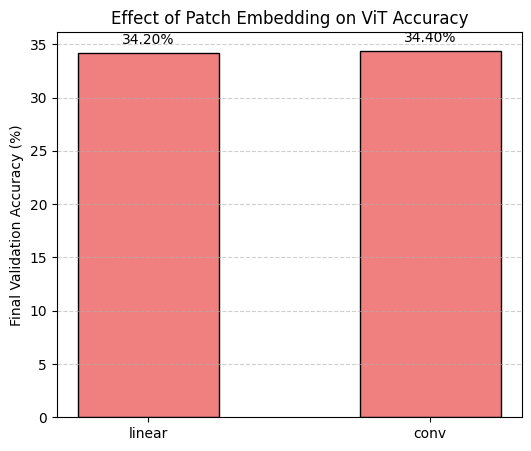

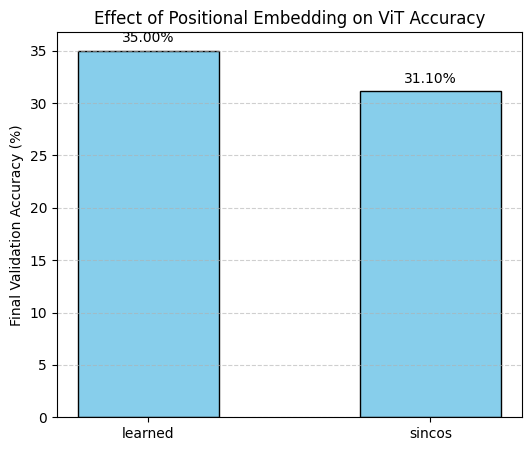

In [37]:
plt.figure(figsize=(6,5))
plt.bar(patch_accs.keys(), patch_accs.values(), color="lightcoral", edgecolor="black", width=0.5)
plt.title("Effect of Patch Embedding on ViT Accuracy")
plt.ylabel("Final Validation Accuracy (%)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
for x, y in patch_accs.items():
    plt.text(x, y+0.5, f"{y:.2f}%", ha="center", va="bottom", fontsize=10)
plt.show()

plt.figure(figsize=(6,5))
plt.bar(pos_accs.keys(), pos_accs.values(), color="skyblue", edgecolor="black", width=0.5)
plt.title("Effect of Positional Embedding on ViT Accuracy")
plt.ylabel("Final Validation Accuracy (%)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
for x, y in pos_accs.items():
    plt.text(x, y+0.5, f"{y:.2f}%", ha="center", va="bottom", fontsize=10)
plt.show()